In [36]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 129.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [37]:
import mlflow
mlflow.end_run()

In [38]:
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path.as_posix()}") #тут мы подключаем mlflow к sqlite базе

In [39]:
experiment_name = 'architecture_styles_classification_final'
experiment = mlflow.get_experiment_by_name(experiment_name)

Мы смотрим есть ли уже такой эксперемент, и если есть подключаемся к нему, если нету создаем новый

In [40]:
if experiment is None:
    experiment_id = mlflow.create_experiment(name = experiment_name, artifact_location=mlflow_artifacts_dir.resolve().as_uri())
else:
    experiment_id = experiment.experiment_id


In [41]:
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///content/drive/MyDrive/GP5_DL_image_classification/mlflow/artifacts', creation_time=1781489901024, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781489901024, lifecycle_stage='active', name='architecture_styles_classification_final', tags={}, trace_location=None, workspace='default'>

In [42]:
print('MLflow подключен к ', mlflow.get_tracking_uri())
print('Куда сохраняються модели:', mlflow_artifacts_dir)

MLflow подключен к  sqlite:////content/drive/MyDrive/GP5_DL_image_classification/mlflow/mlflow.db
Куда сохраняються модели: /content/drive/MyDrive/GP5_DL_image_classification/mlflow/artifacts


##**MyCnn**

**Описание слоев**:

    -> Вход: 3 x 224 x 224
    conv -> 16 x 112 x 112
    conv -> 32 x 56 x 56
    conv -> 64 x 28 x 28
    conv -> 128 x 14 x 14
    conv -> 256 x 7 x 7
    flatten
    fc -> 2048
    fc -> 1024
    fc -> 512
    Выход -> 19

In [43]:
import torch.nn as nn

class MyCnn(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2))

        self.fc1 = nn.Sequential(
            nn.Linear(256 * 7 * 7, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.4))

        self.fc2 = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.4))

        self.fc3 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4))

        self.out = nn.Linear(512, n_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)

        logits = self.out(x)
        return logits


In [44]:
def save_checkpoint(model, optimizer, filename = 'checkpoint.pth', epoch = None, val_macro_f1 = None):
    filename = Path(filename)
    filename.parent.mkdir(parents = True, exist_ok = True)
    checkpoint = {'state_dict': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epoch, 'val_macro_f1': val_macro_f1}
    torch.save(checkpoint, filename)

In [45]:
def load_checkpoint(filepath, model_class, n_classes):
    filepath = Path(filepath)
    checkpoint = torch.load(filepath, map_location=torch.device('cpu'), weights_only=True)
    model = model_class(n_classes)
    model.load_state_dict(checkpoint['state_dict'])
    return model

In [46]:
def fit_epoch(model, train_loader, criterion, optimizer, device = DEVICE):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in tqdm(train_loader, desc='train', leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, dim=1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        processed_data += inputs.size(0)

    train_loss = running_loss / processed_data
    train_acc = running_corrects / processed_data
    return train_loss, train_acc

In [47]:
def eval_epoch(model, val_loader, criterion, device=DEVICE):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(val_loader, desc='valid', leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        processed_size += inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / processed_size
    val_acc = running_corrects / processed_size
    val_macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return val_loss, val_acc, val_macro_f1

In [48]:
def train(train_dataset, val_dataset, model, epochs, batch_size, optimizer, sampler,
          best_state_save_path = 'best_model.pth', run_name = 'experiment', history = None):

    train_loader = DataLoader(train_dataset, batch_size = batch_size, sampler = sampler, shuffle = False, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False, num_workers = 2, pin_memory = True)

    if history is None:
        history = []

    criterion = nn.CrossEntropyLoss()
    best_val_macro_f1 = -67
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id

        mlflow.log_params({
            'architecture': model.__class__.__name__,
            'optimizer': optimizer.__class__.__name__,
            'learning_rate': optimizer.param_groups[0]['lr'],
            'weight_decay': optimizer.param_groups[0].get('weight_decay', 0.0),
            'epochs': epochs,
            'batch_size': batch_size,
            'weighted_sampler': sampler,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'n_classes': len(train_dataset.label_encoder.classes_),
            'seed': seed,
            'rescale_size': rescale_size,
            'dataset_source': 'stepanyarullin/interior-design-styles',
            'selection_metric': 'validation_macro_f1',
            'business_task': 'interior_style_tagging_for_real_estate_platform'})

        with tqdm(desc='epoch', total=epochs, leave=True) as pbar_outer:
            for epoch in range(epochs):
                train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)
                val_loss, val_acc, val_macro_f1 = eval_epoch(model, val_loader, criterion)
                history.append((train_loss, train_acc, val_loss, val_acc, val_macro_f1))
                mlflow.log_metrics({'train_loss': train_loss, 'train_accuracy': train_acc, 'val_loss': val_loss, 'val_accuracy': val_acc, 'val_macro_f1': val_macro_f1}, step = epoch + 1)
                pbar_outer.update(1)

                print(f'\nEpoch {(epoch + 1):03d} train_loss: {train_loss:0.4f} val_loss: {val_loss:0.4f} train_acc: {train_acc:0.4f} acc_val: {val_acc:0.4f} macro_f1_val: {val_macro_f1:0.4f}\n')

                if val_macro_f1 > best_val_macro_f1:
                    best_val_macro_f1 = val_macro_f1
                    save_checkpoint(model = model, optimizer = optimizer, filename = best_state_save_path, epoch = epoch + 1, val_macro_f1 = val_macro_f1)
                    print(f'Новая лучшая модель сохранена: val_macro_f1 = {val_macro_f1:.4f} эпоха = {epoch + 1}')

        mlflow.log_metric('best_val_macro_f1', best_val_macro_f1)
        history_df = pd.DataFrame(history, columns = ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'val_macro_f1'])
        history_path = reports_dir / f'{run_name}_train_history.csv'
        history_df.to_csv(history_path, index=False)
        mlflow.log_artifact(str(history_path), artifact_path='history')

        mlflow.log_artifact(str(best_state_save_path), artifact_path = 'checkpoints')
        mlflow.log_artifact(str(label_encoder_path), artifact_path = 'preprocessing')
        mlflow.log_artifact(str(split_manifest_path), artifact_path = 'data_split')

    return history, run_id


In [49]:
def train(train_dataset, val_dataset, model, epochs, batch_size, optimizer, sampler,
          best_state_save_path = 'best_model.pth', run_name = 'experiment', history = None):

    train_loader = DataLoader(train_dataset, batch_size = batch_size, sampler = sampler, shuffle = False, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False, num_workers = 2, pin_memory = True)

    if history is None:
        history = []

    criterion = nn.CrossEntropyLoss()
    best_val_macro_f1 = -67
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id

        mlflow.log_params({
            'architecture': model.__class__.__name__,
            'optimizer': optimizer.__class__.__name__,
            'learning_rate': optimizer.param_groups[0]['lr'],
            'weight_decay': optimizer.param_groups[0].get('weight_decay', 0.0),
            'epochs': epochs,
            'batch_size': batch_size,
            'weighted_sampler': sampler,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'n_classes': len(train_dataset.label_encoder.classes_),
            'seed': seed,
            'rescale_size': rescale_size,
            'dataset_source': 'stepanyarullin/interior-design-styles',
            'selection_metric': 'validation_macro_f1',
            'business_task': 'interior_style_tagging_for_real_estate_platform'})

        with tqdm(desc='epoch', total=epochs, leave=True) as pbar_outer:
            for epoch in range(epochs):
                train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)
                val_loss, val_acc, val_macro_f1 = eval_epoch(model, val_loader, criterion)
                history.append((train_loss, train_acc, val_loss, val_acc, val_macro_f1))
                mlflow.log_metrics({'train_loss': train_loss, 'train_accuracy': train_acc, 'val_loss': val_loss, 'val_accuracy': val_acc, 'val_macro_f1': val_macro_f1}, step = epoch + 1)
                pbar_outer.update(1)

                print(f'\nEpoch {(epoch + 1):03d} train_loss: {train_loss:0.4f} val_loss: {val_loss:0.4f} train_acc: {train_acc:0.4f} acc_val: {val_acc:0.4f} macro_f1_val: {val_macro_f1:0.4f}\n')

                if val_macro_f1 > best_val_macro_f1:
                    best_val_macro_f1 = val_macro_f1
                    save_checkpoint(model = model, optimizer = optimizer, filename = best_state_save_path, epoch = epoch + 1, val_macro_f1 = val_macro_f1)
                    print(f'Новая лучшая модель сохранена: val_macro_f1 = {val_macro_f1:.4f} epoch = {epoch + 1}')

        mlflow.log_metric('best_val_macro_f1', best_val_macro_f1)
        history_df = pd.DataFrame(history, columns = ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'val_macro_f1'])
        history_path = reports_dir / f'{run_name}_train_history.csv'
        history_df.to_csv(history_path, index=False)
        mlflow.log_artifact(str(history_path), artifact_path='history')

        mlflow.log_artifact(str(best_state_save_path), artifact_path = 'checkpoints')
        mlflow.log_artifact(str(label_encoder_path), artifact_path = 'preprocessing')
        mlflow.log_artifact(str(split_manifest_path), artifact_path = 'data_split')

    return history, run_id


Эти три функции выше у нас обучают(функция обучения связана с двумя другими) и потом проверяю на валидационной выборке

In [50]:
def predict(model, test_loader):
  with torch.no_grad():
    model.eval()
    logits = []
    for inputs in test_loader:
      inputs = inputs.to(DEVICE)
      outputs = model(inputs).cpu()
      logits.append(outputs)
  probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
  return probs

In [51]:
n_classes = len(label_encoder.classes_)
print(f'У нас  19 классов: {n_classes}')

cnn_model = MyCnn(n_classes).to(DEVICE)
print(cnn_model)

У нас  19 классов: 19
MyCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05

In [52]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    print(f"Всего параметров: {total_params}")
    print(f"Обучаемых параметров: {trainable_params}")
    print(f"Не обучаемых параметров: {non_trainable_params}")
    return total_params, trainable_params, non_trainable_params

In [53]:
count_parameters(cnn_model)

Всего параметров: 28725619
Обучаемых параметров: 28725619
Не обучаемых параметров: 0


(28725619, 28725619, 0)

### Обучение

In [54]:
train_sample_counts = Counter(train_dataset.labels)
sample_weights = [1.0 / train_sample_counts[label] for label in train_dataset.labels]
weighted_sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double), num_samples=len(sample_weights), replacement=True)

In [55]:
from sklearn.metrics import f1_score

In [56]:
my_cnn_epochs = 30
batch_size = 128

optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

history, cnn_run_id = train(
    train_dataset = train_dataset,
    val_dataset = val_dataset,
    model = cnn_model,
    epochs = my_cnn_epochs,
    batch_size = batch_size,
    optimizer = optimizer,
    sampler = weighted_sampler,
    best_state_save_path = checkpoints_dir / 'my_cnn_best.pth',
    run_name = 'MyCnn_AdamW1')

epoch:   0%|          | 0/30 [00:00<?, ?it/s]

train:   0%|          | 0/93 [00:00<?, ?it/s]

valid:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 001 train_loss: 2.8641 val_loss: 2.8685 train_acc: 0.1096 acc_val: 0.1106 macro_f1_val: 0.0722

Новая лучшая модель сохранена: val_macro_f1 = 0.0722 epoch = 1


train:   0%|          | 0/93 [00:00<?, ?it/s]

...

valid:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 029 train_loss: 0.6179 val_loss: 3.8499 train_acc: 0.8119 acc_val: 0.2087 macro_f1_val: 0.2089



train:   0%|          | 0/93 [00:00<?, ?it/s]

valid:   0%|          | 0/24 [00:00<?, ?it/s]


Epoch 030 train_loss: 0.5977 val_loss: 3.9475 train_acc: 0.8177 acc_val: 0.2103 macro_f1_val: 0.2064



In [57]:
#heckpoint = torch.load('checkpoint.pth')

#cnn_model = MyCnn(n_classes=n_classes)
#cnn_model.load_state_dict(checkpoint['state_dict'])

#optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
#optimizer.load_state_dict(checkpoint['optimizer'])

#start_epoch = checkpoint['epoch'] + 1
#best_val_macro_f1 = checkpoint['val_macro_f1']

### Кривые обучения

In [58]:
loss, acc, val_loss, val_acc, val_macro_f1 = zip(*history)

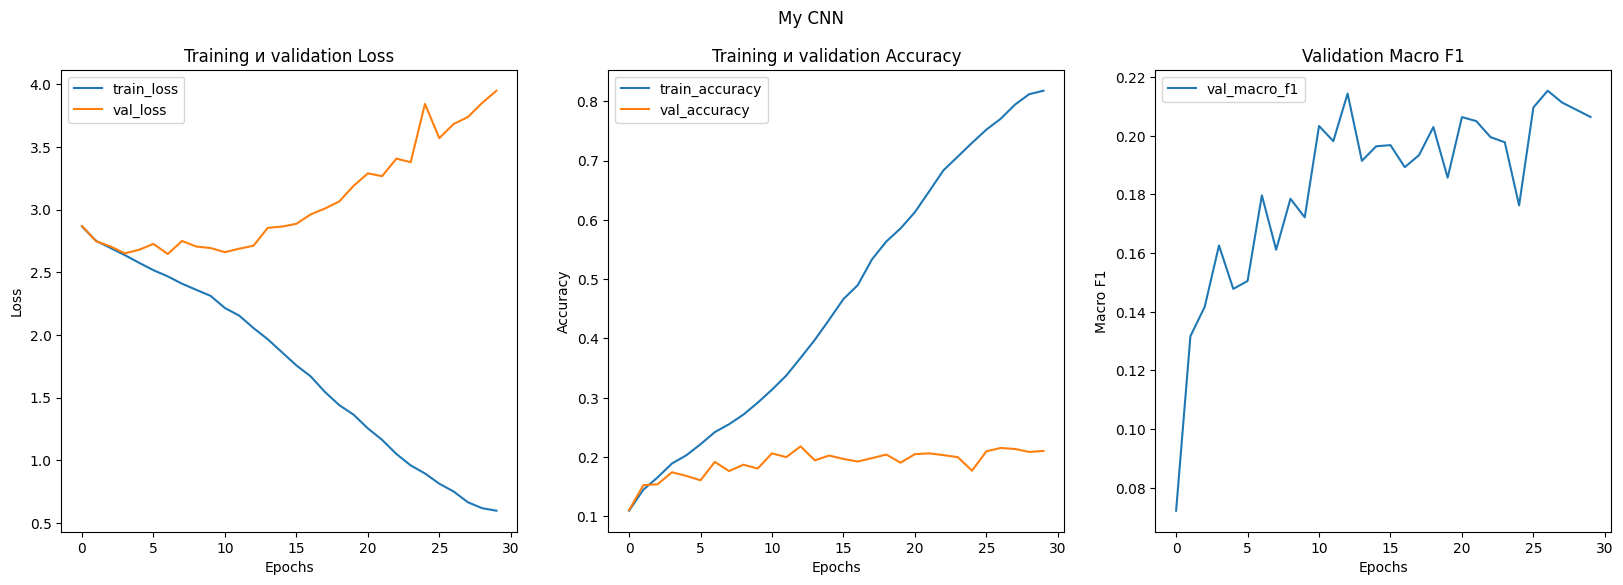

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('My CNN')

axes[0].plot(loss, label='train_loss')
axes[0].plot(val_loss, label='val_loss')
axes[0].legend(loc='best')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training и validation Loss')

axes[1].plot(acc, label='train_accuracy')
axes[1].plot(val_acc, label='val_accuracy')
axes[1].legend(loc='best')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training и validation Accuracy')

axes[2].plot(val_macro_f1, label='val_macro_f1')
axes[2].legend(loc='best')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Macro F1')
axes[2].set_title('Validation Macro F1')

plt.show()

### Предсказание

Для итогового предсказания используется модель с максимальным значением
macro F1 на валидационной выборке.

In [60]:
cnn_model_best = load_checkpoint(checkpoints_dir / 'my_cnn_best.pth', MyCnn, n_classes)
cnn_model_best.to(DEVICE)
cnn_model_best.eval()

MyCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine

In [61]:
def predict_one_sample(model, inputs, device = DEVICE):
  with torch.no_grad():
    inputs = inputs.to(device)
    model.eval()
    logit = model(inputs).cpu()
    probs = torch.nn.functional.softmax(logit, dim = -1).numpy()
  return probs

In [62]:
label_encoder = pickle.load(open(label_encoder_path, 'rb'))

### Метрика

Метрика, которую необходимо оптимизировать - *f1-score*. Вычислим целевую метрику на тестовой выборке.

In [63]:
label_encoder = pickle.load(open(label_encoder_path, 'rb'))

test_dataset = InteriorDataset(test_files, mode = 'test')
test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 128)

In [64]:
probs = predict(cnn_model_best, test_loader)
y_pred = np.argmax(probs, axis = 1)

In [65]:
label_encoder = pickle.load(open(label_encoder_path, 'rb'))
preds_class = label_encoder.inverse_transform(y_pred)

In [66]:
test_filenames = [path.name for path in test_dataset.files]

In [69]:
test_labels_df = pd.read_csv(test_csv)
predictions_df = pd.DataFrame({'filename': test_filenames, 'predicted': preds_class})
merged_df = test_labels_df.merge(predictions_df, on = 'filename', how = 'inner', validate = 'one_to_one')

In [70]:
assert len(merged_df) == len(test_labels_df), ('Пикчи не найдены')

In [71]:
my_cnn_predictions_path = predictions_dir / 'my_cnn_predictions.csv'
merged_df.to_csv(my_cnn_predictions_path, index = False, encoding = 'utf-8')

In [72]:
test_macro_f1 = f1_score(merged_df['style'], merged_df['predicted'], average='macro', zero_division=0)
test_micro_f1 = f1_score(merged_df['style'], merged_df['predicted'], average='micro', zero_division=0)
print('Test macro F1:', test_macro_f1)
print('Test micro F1:', test_micro_f1)

Test macro F1: 0.20588382305940497
Test micro F1: 0.20595333869670152


In [73]:
with mlflow.start_run(run_id = cnn_run_id):
    mlflow.log_metrics({'test_macro_f1': test_macro_f1, 'test_micro_f1': test_micro_f1})
    mlflow.log_artifact(str(my_cnn_predictions_path), artifact_path = 'predictions')

In [74]:
runs = mlflow.search_runs(experiment_names = [experiment_name])
columns = ['tags.mlflow.runName', 'params.architecture', 'params.learning_rate', 'params.batch_size', 'metrics.best_val_macro_f1', 'metrics.test_macro_f1']

In [75]:
display(runs.reindex(columns = columns))

,tags.mlflow.runName,params.architecture,params.learning_rate,params.batch_size,metrics.best_val_macro_f1,metrics.test_macro_f1
0,MyCnn_AdamW1,MyCnn,0.001,128,0.215364,0.205884
1,MyCnn_AdamW1,MyCnn,0.001,128,NaN,NaN
2,MyCnn_AdamW1,MyCnn,0.001,128,NaN,NaN


### Визуализация уверенности модели в предсказаниях

In [82]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties


def imshow(image, title, plt_ax):
    image = image.detach().cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    if plt_ax is None:
        plt_ax = plt.gca()
    plt_ax.imshow(image)
    plt_ax.axis('off')
    plt_ax.set_title(title)

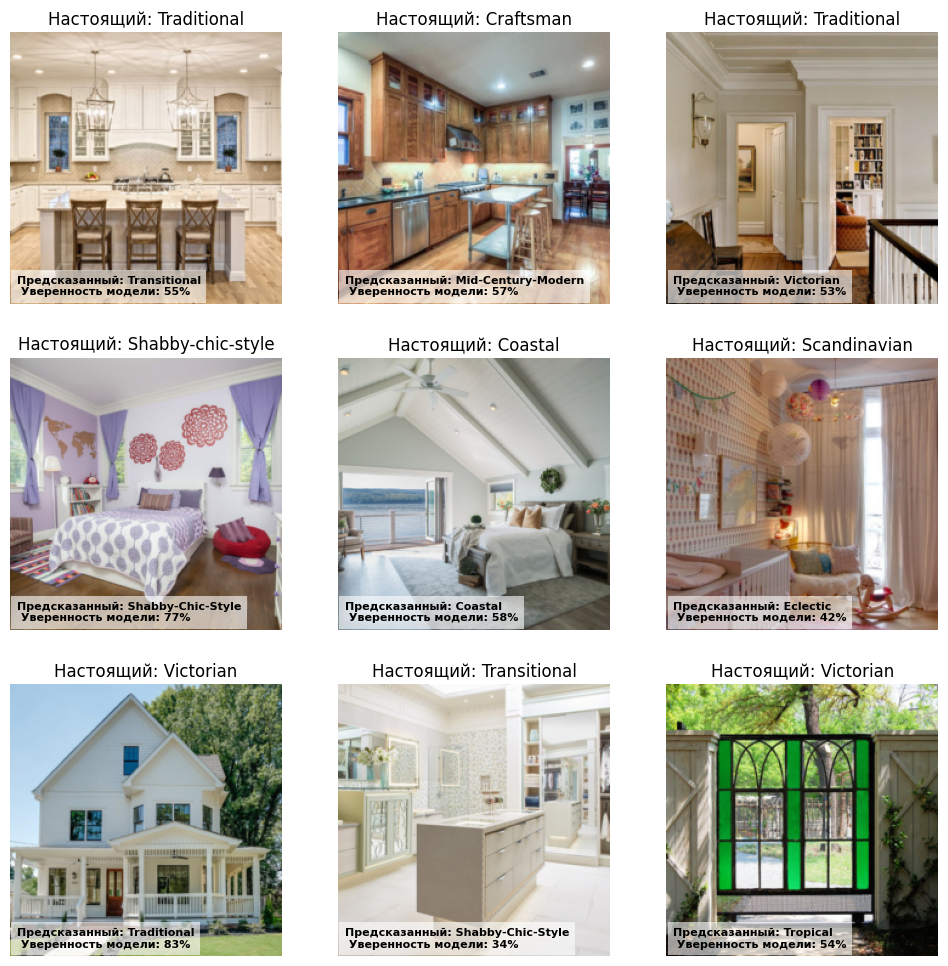

In [83]:
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (12, 12), sharey = True, sharex = True)
for x in ax.flatten():
    random_character = np.random.randint(0, len(val_dataset))
    im_val, label = val_dataset[random_character]
    img_label = ' '.join(map(lambda x: x.capitalize(), val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val, title = f'Настоящий: {img_label}', plt_ax = x)

    inputs = im_val.unsqueeze(0)
    prob_pred = predict_one_sample(cnn_model_best, inputs)[0]
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_proba = prob_pred[y_pred] * 100
    predicted_label = predicted_label.replace('_', ' ').title()
    predicted_text = 'Предсказанный: {}\n Уверенность модели: {:.0f}%'.format(predicted_label, predicted_proba)

    x.text(0.025, 0.025, predicted_text, transform = x.transAxes, horizontalalignment = 'left', verticalalignment = 'bottom', fontsize = 8, color = 'black', fontweight = 'bold', bbox = {'facecolor': 'white', 'alpha': 0.6, 'edgecolor': 'none'})

plt.show()